In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap

In [2]:
#Cargar el DataFrame original
df = pd.read_csv('spotify.csv')

/var/folders/9f/033njbc56m1gyr8cq8d9vtsc0000gn/T/ipykernel_69652/3571122630.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('spotify.csv')


In [3]:
#Ver las primeras filas
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN


In [4]:
#Eliminar columnas irrelevantes
df_cleaned = df.copy()


In [5]:
cols_to_drop = [
    'type',
    'id',
    'uri',
    'track_href',
    'analysis_url',
    'genre',
    'song_name',
    'title',
    'Unnamed: 0'
]

cols_to_drop = [c for c in cols_to_drop if c in df_cleaned.columns]  # por si alguna no está

df_cleaned = df_cleaned.drop(columns=cols_to_drop)


In [6]:
#Eliminar filas con valores nulos o duplicados
df_cleaned = df_cleaned.dropna().drop_duplicates()


In [7]:
#Revisar el DataFrame limpio
df_cleaned.info()
df_cleaned.head()


<class 'pandas.core.frame.DataFrame'>
Index: 35093 entries, 0 to 42304
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      35093 non-null  float64
 1   energy            35093 non-null  float64
 2   key               35093 non-null  int64  
 3   loudness          35093 non-null  float64
 4   mode              35093 non-null  int64  
 5   speechiness       35093 non-null  float64
 6   acousticness      35093 non-null  float64
 7   instrumentalness  35093 non-null  float64
 8   liveness          35093 non-null  float64
 9   valence           35093 non-null  float64
 10  tempo             35093 non-null  float64
 11  duration_ms       35093 non-null  int64  
 12  time_signature    35093 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 3.7 MB


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,4
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,4
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,4
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,3
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,4


In [8]:
#Verificar los tipos de datos
df_cleaned.dtypes


danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
dtype: object

In [9]:
#Convertir columnas a tipo numérico
df_cleaned = df_cleaned.select_dtypes(include=['int64', 'float64'])


In [10]:
#Verificamos los tipos de datos nuevamente
df_cleaned.dtypes


danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
dtype: object

In [11]:
df_cleaned.select_dtypes(include=['object']).columns


Index([], dtype='object')

In [12]:
df_num = df_cleaned.select_dtypes(include=['int64', 'float64'])


In [13]:
import numpy as np
df_num = df_num.replace([np.inf, -np.inf], np.nan)
df_num = df_num.dropna()


In [14]:
df_num.dtypes


danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
dtype: object

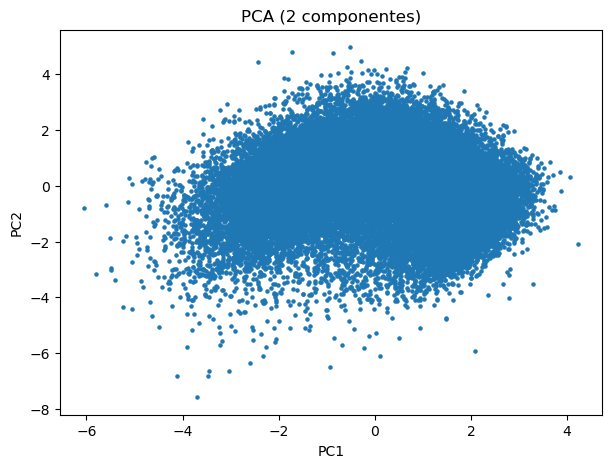

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# columnas de audio que vamos a usar para PCA y luego K-means
cols_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms',
    'time_signature'
]

df_num = df_cleaned[cols_features]

# por si acaso: quitar NaN que hayan quedado
df_num = df_num.dropna()

# ESCALADO
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_num)

# PCA 2 componentes
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# PLOT PCA
plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], s=5)
plt.title("PCA (2 componentes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


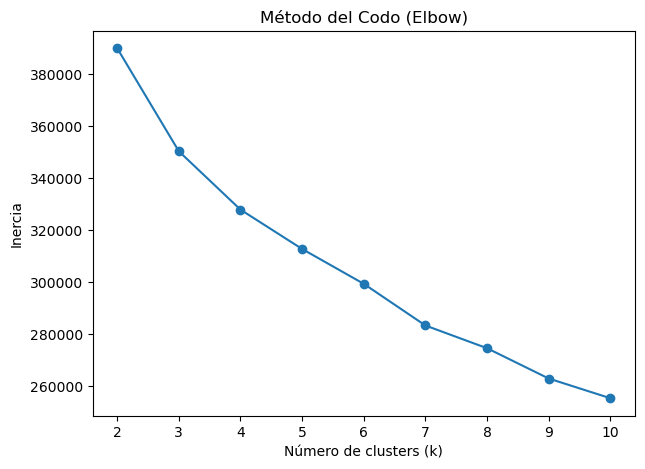

In [16]:
#ELBOW METHOD
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

K_range = range(2, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)          # usamos TODAS las features escaladas
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo (Elbow)")
plt.show()


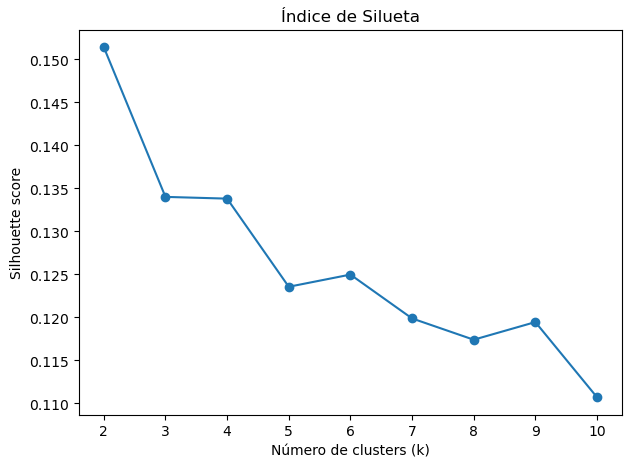

In [17]:
#SILHOUETTE SCORE
from sklearn.metrics import silhouette_score

silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(scaled_data)
    silhouettes.append(silhouette_score(scaled_data, labels_k))

plt.figure(figsize=(7,5))
plt.plot(K_range, silhouettes, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Índice de Silueta")
plt.show()


El método del codo sugiere un cambio de pendiente alrededor de k = 4.
El índice de Silhouette muestra que los valores más altos se encuentran entre k=3 y k=4,
por lo que elegimos k=4 como compromiso entre cohesión e interpretación.

In [20]:
from sklearn.cluster import KMeans

k_optimo = 4

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(scaled_data)

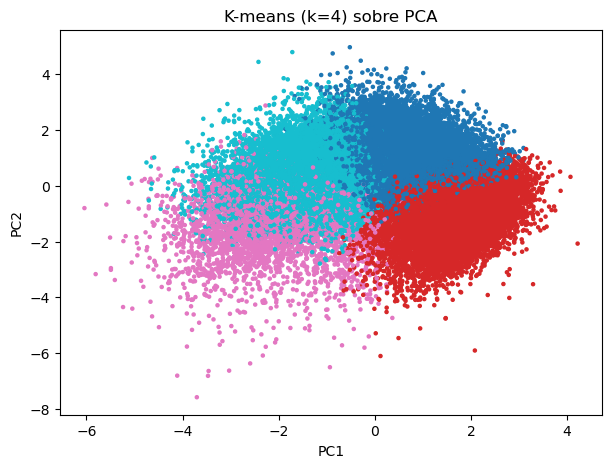

In [ ]:
#Aplicar K óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(scaled_data)
plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels, cmap='tab10', s=5)
plt.title(f"K-means (k={k_optimo}) sobre PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Tanto el método del codo como el índice de Silhouette indicaron que la mejor solución para K-means se encuentra entre k=3 y k=4.
Al representar los clusters sobre las componentes principales del PCA, observamos que k=4 produce grupos más definidos y interpretables, separando bien canciones energéticas, canciones equilibradas, canciones intermedias y canciones más acústicas.
Por este motivo se seleccionó k = 4 como la solución óptima.